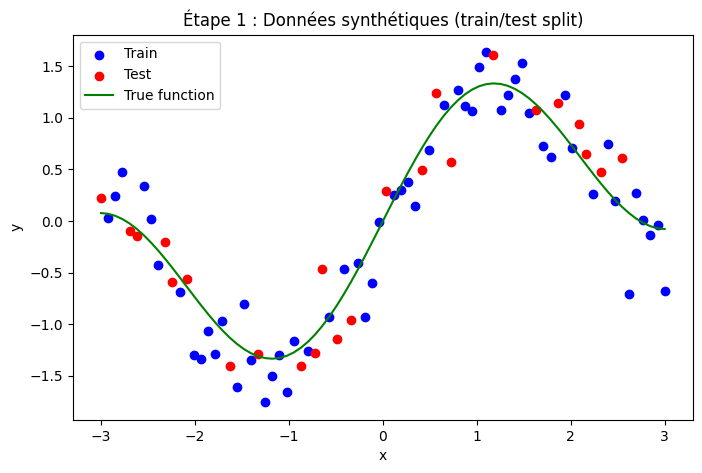

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 1. Générer un échantillon de points x
np.random.seed(42)
x=np.linspace(-3,3,80).reshape(-1,1)
y_true=np.sin(1.5*x).ravel()+0.3*x.ravel()
y=y_true+np.random.normal(0,0.3,x.shape[0])
df=pd.DataFrame({"x":x.ravel(),"y":y})

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color='blue', label='Train')
plt.scatter(X_test, y_test, color='red', label='Test')
plt.plot(x, y_true, color='green', label='True function')
plt.legend()
plt.title("Étape 1 : Données synthétiques (train/test split)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


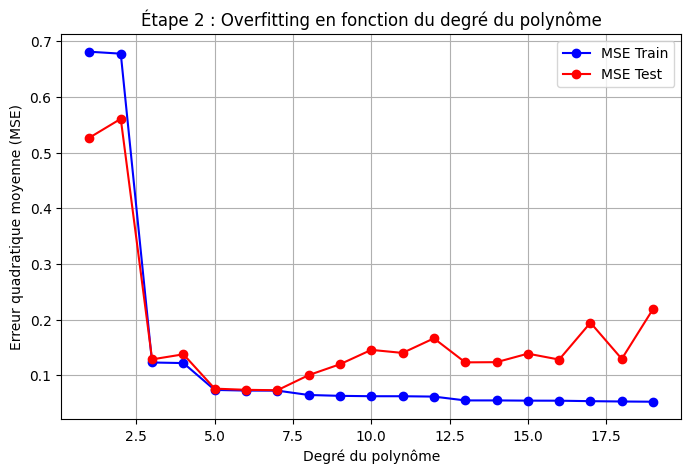

In [13]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

degrees = range(1, 20)

mse_train = []
mse_test = []

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    mse_train.append(mean_squared_error(y_train, y_train_pred))
    mse_test.append(mean_squared_error(y_test, y_test_pred))

plt.figure(figsize=(8, 5))
plt.plot(degrees, mse_train, marker='o', label='MSE Train', color='blue')
plt.plot(degrees, mse_test, marker='o', label='MSE Test', color='red')
plt.xlabel("Degré du polynôme")
plt.ylabel("Erreur quadratique moyenne (MSE)")
plt.title("Étape 2 : Overfitting en fonction du degré du polynôme")
plt.legend()
plt.grid(True)
plt.show()


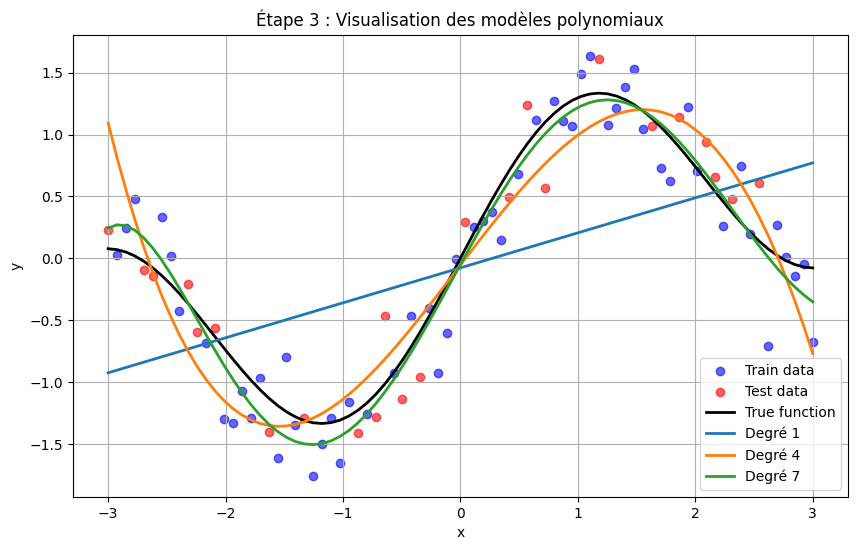

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

degrees_to_plot = [1, 4,7]

X_plot = x
y_true_plot = y_true

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='blue', label='Train data', alpha=0.6)
plt.scatter(X_test, y_test, color='red', label='Test data', alpha=0.6)
plt.plot(X_plot, y_true_plot, color='black', linewidth=2, label='True function')

for d in degrees_to_plot:
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_plot_poly = poly.transform(X_plot)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    y_plot_pred = model.predict(X_plot_poly)

    plt.plot(X_plot, y_plot_pred, linewidth=2, label=f"Degré {d}")

plt.title("Étape 3 : Visualisation des modèles polynomiaux")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()


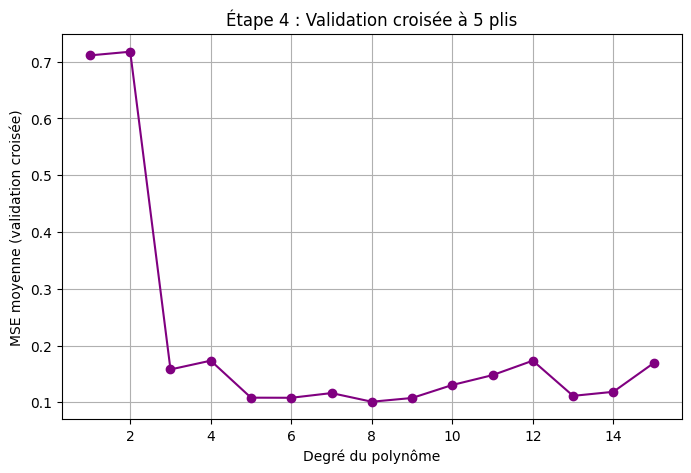

✅ Degré optimal (min MSE CV): 8


In [21]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

degrees = range(1, 16)
mse_cv_mean = []

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for d in degrees:
    model = make_pipeline(PolynomialFeatures(degree=d), LinearRegression())
    
    mse_scores = -cross_val_score(model, X_train, y_train,
                                  scoring='neg_mean_squared_error',
                                  cv=kfold)
        
    mse_cv_mean.append(mse_scores.mean())

# Plot average CV error
plt.figure(figsize=(8, 5))
plt.plot(degrees, mse_cv_mean, marker='o', color='purple')
plt.xlabel("Degré du polynôme")
plt.ylabel("MSE moyenne (validation croisée)")
plt.title("Étape 4 : Validation croisée à 5 plis")
plt.grid(True)
plt.show()

# Find optimal degree
best_degree = degrees[np.argmin(mse_cv_mean)]
print(f"✅ Degré optimal (min MSE CV): {best_degree}")


c:\Users\chikh\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.64311e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\chikh\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.59871e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\chikh\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.85475e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\chikh\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.65522e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\chikh\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\_lib\

✅ Best alpha: 0.0001
MSE (Train Ridge): 0.0546
MSE (Test Ridge):  0.1389

Without Ridge:
MSE (Train): 0.0546
MSE (Test):  0.1390


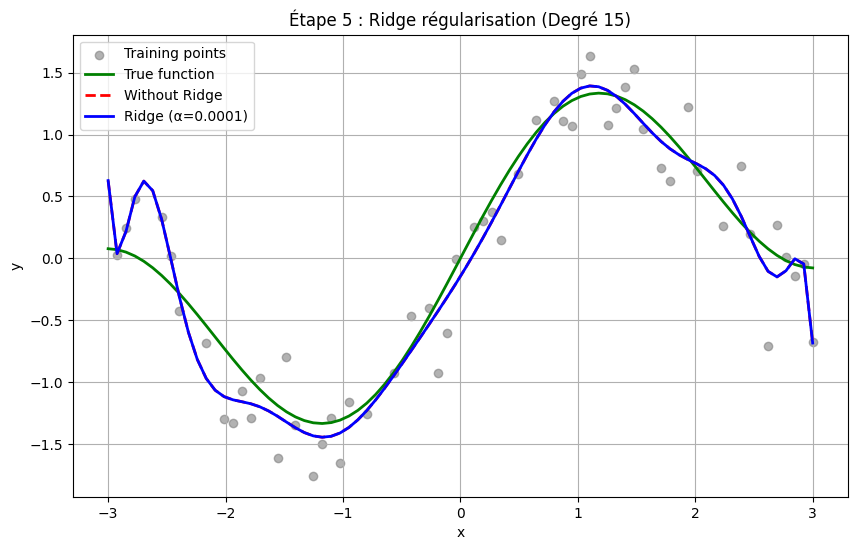

In [25]:
# Étape 5 : Régression Ridge
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Choose a high polynomial degree (deliberately complex)
degree = 15

# Create pipeline (PolynomialFeatures + Ridge)
model_ridge = make_pipeline(PolynomialFeatures(degree=degree), Ridge())

# Define grid of alpha values (regularization strength)
alphas = np.logspace(-4, 3, 50)  # from 1e-4 to 1e3

# GridSearch with 5-fold CV to find best alpha
param_grid = {'ridge__alpha': alphas}
grid = GridSearchCV(model_ridge, param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train, y_train)

# Best alpha
best_alpha = grid.best_params_['ridge__alpha']
print(f"✅ Best alpha: {best_alpha:.4f}")

# Evaluate model with best alpha
best_ridge = grid.best_estimator_
y_train_pred_ridge = best_ridge.predict(X_train)
y_test_pred_ridge = best_ridge.predict(X_test)

mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)
mse_test_ridge = mean_squared_error(y_test, y_test_pred_ridge)
print(f"MSE (Train Ridge): {mse_train_ridge:.4f}")
print(f"MSE (Test Ridge):  {mse_test_ridge:.4f}")

# Compare to unregularized model (same degree)
from sklearn.linear_model import LinearRegression
poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
model_lin = LinearRegression()
model_lin.fit(X_train_poly, y_train)
mse_train_lin = mean_squared_error(y_train, model_lin.predict(X_train_poly))
mse_test_lin = mean_squared_error(y_test, model_lin.predict(X_test_poly))
print(f"\nWithout Ridge:")
print(f"MSE (Train): {mse_train_lin:.4f}")
print(f"MSE (Test):  {mse_test_lin:.4f}")

# Plot the fits for visual comparison
X_plot = x
y_true_plot = y_true
y_lin_plot = model_lin.predict(poly.transform(X_plot))
y_ridge_plot = best_ridge.predict(X_plot)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='gray', alpha=0.6, label='Training points')
plt.plot(X_plot, y_true_plot, color='green', linewidth=2, label='True function')
plt.plot(X_plot, y_lin_plot, color='red', linestyle='--', linewidth=2, label='Without Ridge')
plt.plot(X_plot, y_ridge_plot, color='blue', linewidth=2, label=f'Ridge (α={best_alpha:.3g})')
plt.title(f"Étape 5 : Ridge régularisation (Degré {degree})")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
